In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')


In [13]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


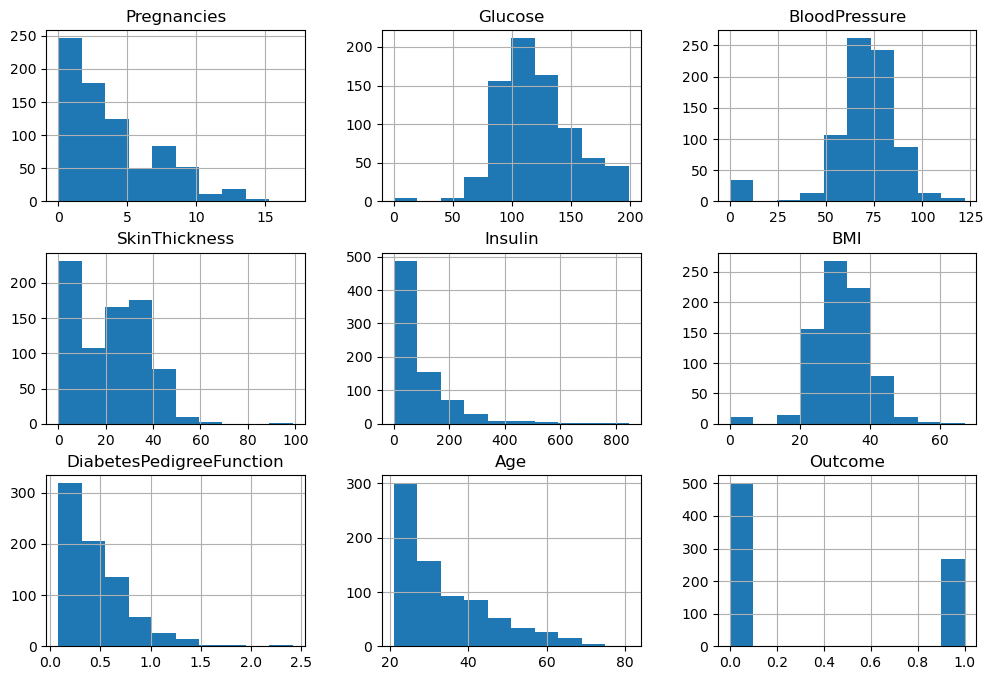

In [17]:
df.hist(figsize=(12,8))
plt.show()

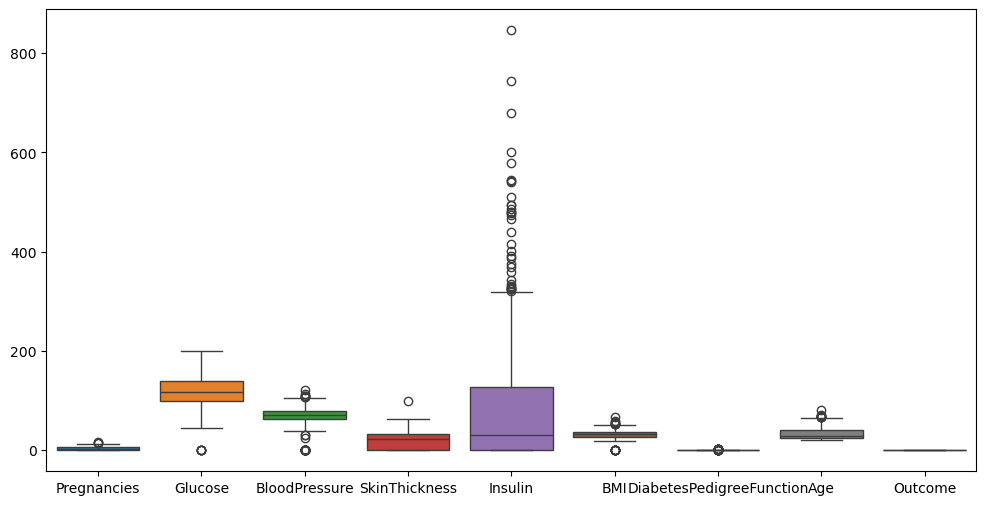

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

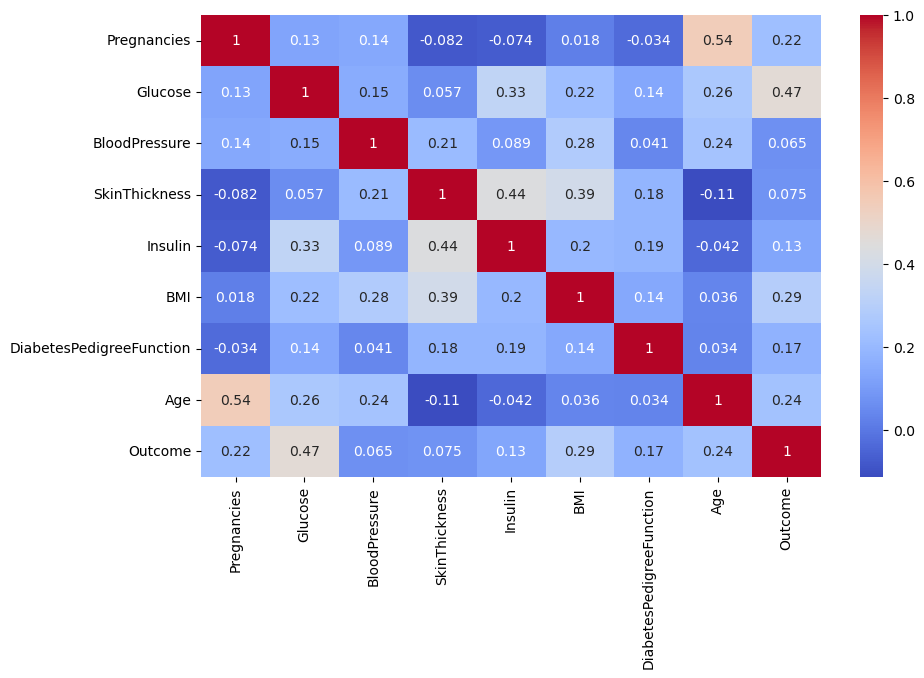

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Data Preprocessing

In [20]:
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols_with_zero:
    df[col].replace(0, df[col].median(), inplace=True)


In [21]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Model Building

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Model Evaluation

In [25]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [26]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1-Score:", f1_score(y_test,y_pred))
print("ROC-AUC:", roc_auc_score(y_test,y_prob))

Accuracy: 0.7662337662337663
Precision: 0.6792452830188679
Recall: 0.6545454545454545
F1-Score: 0.6666666666666666
ROC-AUC: 0.8196510560146923


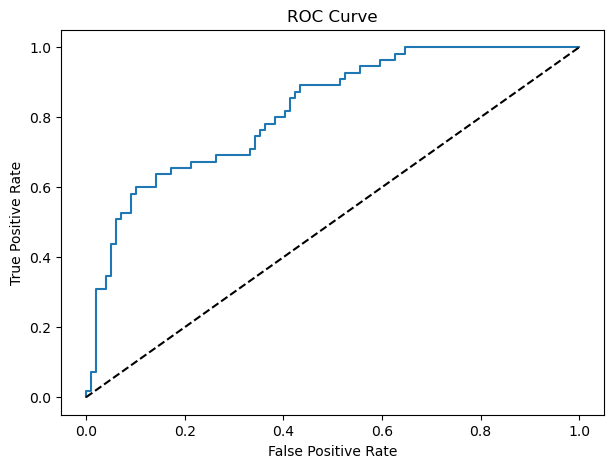

In [27]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
1,Glucose,1.150522
5,BMI,0.712522
7,Age,0.387256
0,Pregnancies,0.222140
6,DiabetesPedigreeFunction,0.213286
3,SkinThickness,0.051662
2,BloodPressure,-0.165550
4,Insulin,-0.222430


Positive Coefficient → Increases probability of diabetes
Negative Coefficient → Decreases probability


In [29]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


Interview Question

1. What is the difference between precision and recall?Precision tells us out of all the predictions the model said are “positive,” how many were actually correct.Recall tells us out of all the actual positive cases in the data, how many the model was able to detect.
Example:
If we are detecting a disease:
Precision = Out of people predicted “diseased,” how many truly have the disease
Recall = Out of all people who actually have the disease, how many the model found

2.What is cross-validation, and why is it important in binary classification?
Cross-validation is a method where we split the dataset into multiple small parts (called “folds”).
The model is trained on some folds and tested on the remaining fold.
This process repeats several times, and we take the average performance.
It gives a more reliable accuracy because the model is tested on multiple different subsets.
It helps avoid overfitting, where the model performs well on training data but poorly on new data.
It uses the dataset efficiently, especially when data is limited